## Simulating traffic and saltwater intrusion
In this notebook, we simulate a lock complex on a network. Like in notebooks 204 and 205, randomly generated, evenly sized vessels sampled from an exponential distribution have to pass this lock. We add a complex lock object to the graph. Vessels are levelled in the same lock operation if they can fit inside the lock and register with the lock operator before the start of the lock operation. We now include a tidal water level at one side of the lock, and we will observe the levelling times to fluctuate. Moreover, we salt concentrations on both sides of the lock. Due to the lock operation, levelling and gate-open phases emerge that cause salt transport. We quantify the fluxes based on the [pyZSF](https://pypi.org/project/pyzsf/) package of Deltares using a method called the [Zeesluisformulering](https://github.com/Deltares/D-SLF) (translated to English: Sea Lock Formulation).

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object, generate_vessels_from_distribution
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of util for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# import of mixin to include hydrodynamic data in the simulation
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd

# packege(s) needed to create hydrodynamic data
import xarray as xr

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


#### 0. Create environment
We create an environment with a simulation start and stop as parameters.

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2025, 1, 3, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
We create a directed graph, naming the nodes as 'Sea #' and 'Canal #' to distinguish between the saltwater and freshwater sides of the lock.

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('Sea -1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-25000,0)))
graph.add_node('Sea 0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('Canal 0',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('Canal 1',geometry=transform(wgs84eqd_to_wgs84rad,Point(25000,0)))

# add edges
graph.add_edge('Sea -1','Sea 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-25000, 0),Point(-5000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('Sea 0','Sea -1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('Sea 0','Canal 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('Canal 0','Sea 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
graph.add_edge('Canal 0','Canal 1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('Canal 1','Canal 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(25000, 0),Point(5000, 0)])), weight=1, length_m=25000-5000)

# add graph to environment
env.graph = graph

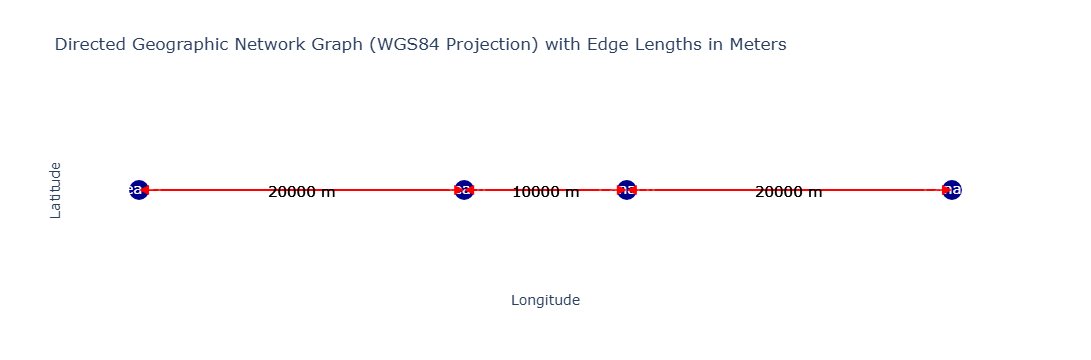

In [4]:
plot_graph(graph)

#### 1+ Adding environmental data
We add the environmental data. The water level at sea is tidal, while the canal has a constant water level. We also have to specify Salinity and Temperature, which we assume are constant on both sides.

In [5]:
hydrodynamic_data = xr.Dataset()

stations = ['Canal 0', 'Sea 0']
time = pd.date_range(start = simulation_start,
                     end = simulation_stop,
                     freq = pd.Timedelta(minutes=5))


# Water level
static_water_level = np.zeros(len(time))
tidal_amplitude = 1.0
tidal_period = 12.5 #hours
tidal_water_level = [tidal_amplitude*np.sin(2*np.pi*(t-simulation_start).total_seconds()/(tidal_period*3600)) for t in time]
water_level_data = xr.DataArray(data=[static_water_level,tidal_water_level],coords={'STATION':stations,'TIME':time})
hydrodynamic_data['Water level'] = water_level_data

# Salinity
static_salinity_sea = 25.0*np.ones(len(time))
static_salinity_canal = 5.0*np.ones(len(time))
salinity_data = xr.DataArray(data=[static_salinity_canal,static_salinity_sea],coords={'STATION':stations,'TIME':time})
hydrodynamic_data['Salinity'] = salinity_data

# Water temperature
static_temperature_sea = 15.0*np.ones(len(time))
static_temperature_canal = 15.0*np.ones(len(time))
temperature_data = xr.DataArray(data=[static_temperature_canal,static_temperature_sea],coords={'STATION':stations,'TIME':time})
hydrodynamic_data['Temperature'] = temperature_data

We add the data to the environment:

In [6]:
HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data);

#### 1+ Adding infrastructure
We add the lock complex:

In [7]:
lock_chamber = IsLockChamber(env=env,
                             lock_depth = 10,
                             name='Lock',
                             gate_open = 'Sea 0',
                             edge = ('Sea 0','Canal 0'),
                             geometry_m = Polygon([Point(-200, -25),Point(-200, 25),Point(200, 25),Point(200, -25)]))

In [8]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('Sea 0','Canal 0'),
                                   orientation = 0,
                                   distance_from_edge_start = 0)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('Canal 0','Sea 0'),
                                   orientation = 1,
                                   distance_from_edge_start = 0)

In [9]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['Sea 0','Canal 0'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
And create agents:

In [10]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [11]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [12]:
upstream_vessels = generate_vessels_from_distribution(env=env,
                                                      VesselClass = Vessel,
                                                      vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                      mean_arrival_rate=30.,
                                                      number_of_vessels=10,
                                                      start_node = 'Sea -1',
                                                      end_node = 'Canal 1',
                                                      seed = 123)

downstream_vessels = generate_vessels_from_distribution(env=env,
                                                        VesselClass = Vessel,
                                                        vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                        mean_arrival_rate=30.,
                                                        number_of_vessels=10,
                                                        start_node = 'Canal 1',
                                                        end_node = 'Sea -1',
                                                        seed = 456)

vessels = upstream_vessels + downstream_vessels

for vessel in vessels:
    env.process(mission(env, vessel))

#### 3. Run simulation

In [13]:
env.run()

#### 4. Inspect output

#### Gantt chart of event table

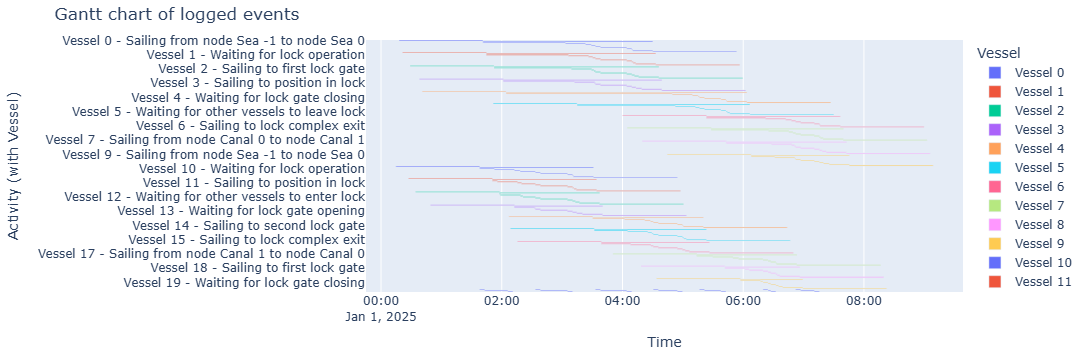

In [14]:
df_eventtable = logbook2eventtable([*vessels, lock_chamber])
fig = generate_vessel_gantt_chart(df_eventtable)

#### Time-distance diagram of vessels passing the lock, and water level and salinity variations
We will now see the salt concentration and salt mass of the lock chamber vary over time. This is due to the following processes:

##### 1 - Density currents
You can observe the impact of gate-open phases, characterised by an increase or decrease in salt concentration according to the hyperbolic tangent, depending on whether the canalside or seaside gate has been opened. 

##### 2 - Vessels sailing into and out of the lock
The impact of sailing in and out of vessels on the saltwater intrusion can be observed. The salt mass decreases when vessels sail into the lock (occupying volume), while the salt concentration remains the same. In contrast, the salt mass increases when vessels sail out, increasing or decreasing the salt concentration, whether the vessels sail into the canal or the sea. 

##### 3 - Levelling
During levelling, the salt mass decreases when the lock is being emptied. However, the salt concentration and salt mass increase when the lock is being levelled to the sea, when the water level at sea is greater than at the channel. In contrast, the salt concentration decreases while the salt mass slightly increases, when the lock is being levelled to the canal, when the water level at the canal is greater than at sea.

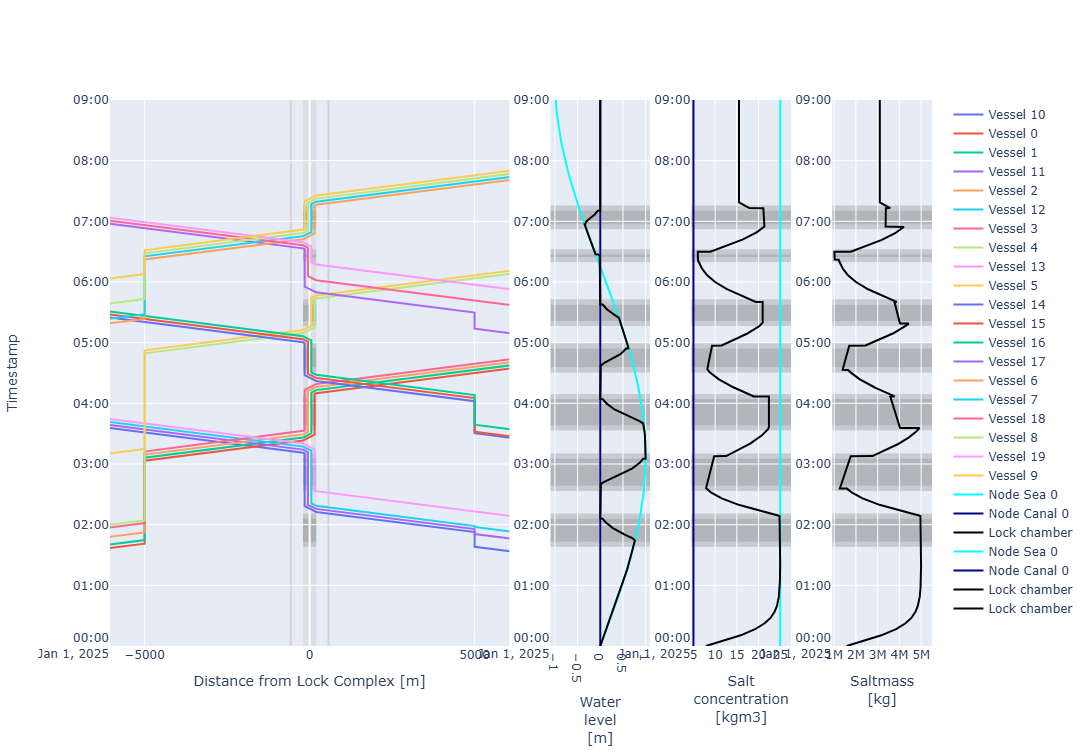

In [15]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -6050, 
                        xlimmax = 6050,
                        ylimmin = pd.Timestamp('2025-01-01 00:00:00'),
                        ylimmax = pd.Timestamp('2025-01-01 09:00:00'),
                        method='Plotly',
                        boundary_nodes = ['Sea -1','Canal 1'])

fig.update_layout(height=cm_to_pixels(20))

#### Saltwater intrusion
The results of the salt concentration time series are based on the results of the [pyZSF](https://pypi.org/project/pyzsf/)-package, applied at every instance that the doors of the lock are closed. A ZSF-eventtable can be created, which is stored as an object of the lock chamber:

In [16]:
lock_chamber.zsf_events

,,head_sea,head_lake,routine,salinity_sea,salinity_lake,ship_volume_lake_to_sea,ship_volume_sea_to_lake,t_level,t_open_lake,t_open_sea,temperature_lake,temperature_sea
time_start,time_stop,,,,,,,,,,,,
2025-01-01 00:00:00,2025-01-01 01:40:34.354414,0.0,0.0,Gate open at sea,25.0,5.0,0.0,0.0,0,0,6034.354414,15.0,15.0
2025-01-01 01:40:34.354414,2025-01-01 02:08:34.354414,0.746247,0.0,Levelling to lake,25.0,5.0,0.0,0.0,1680.0,0,0,15.0,15.0
2025-01-01 02:08:34.354414,2025-01-01 02:35:54.006006,0.880419,0.0,Gate open at lake,25.0,5.0,40000.0,0.0,0,1639.651592,0,15.0,15.0
2025-01-01 02:35:54.006006,2025-01-01 03:07:54.006006,0.999781,0.0,Levelling to sea,25.0,5.0,40000.0,0.0,1920.0,0,0,15.0,15.0
2025-01-01 03:07:54.006006,2025-01-01 03:35:36.198231,0.999781,0.0,Gate open at sea,25.0,5.0,40000.0,40000.0,0,0,1662.192225,15.0,15.0
2025-01-01 03:35:36.198231,2025-01-01 04:06:46.198231,0.972329,0.0,Levelling to lake,25.0,5.0,0.0,40000.0,1870.0,0,0,15.0,15.0
2025-01-01 04:06:46.198231,2025-01-01 04:33:05.582680,0.879074,0.0,Gate open at lake,25.0,5.0,30000.0,40000.0,0,1579.384449,0,15.0,15.0
2025-01-01 04:33:05.582680,2025-01-01 04:57:05.582680,0.607247,0.0,Levelling to sea,25.0,5.0,30000.0,0.0,1440.0,0,0,15.0,15.0
2025-01-01 04:57:05.582680,2025-01-01 05:19:02.159354,0.607247,0.0,Gate open at sea,25.0,5.0,30000.0,20000.0,0,0,1316.576674,15.0,15.0


The resulting fluxes are stored as another object of the lock chamber:

In [17]:
lock_chamber.ZSF_results

,time_start,time_stop,head_sea,head_lake,routine,salinity_sea,salinity_lake,ship_volume_lake_to_sea,ship_volume_sea_to_lake,t_level,...,salinity_lock_start,saltmass_lock_start,volume_ship_in_lock_start,head_lock_start,salinity_lock_stop,saltmass_lock_stop,volume_ship_in_lock_stop,head_lock_stop,salinity_to_lake,salinity_to_sea
0,2025-01-01 00:00:00.000000,2025-01-01 01:40:34.354414,0.0,0.0,Gate open at sea,25.0,5.0,0.0,0.0,0,...,7.880234,1.576047e+06,0.0,0.000000,24.997682,4.999536e+06,0.0,0.000000,NaN,NaN
1,2025-01-01 01:40:34.354414,2025-01-01 02:08:34.354414,0.746247,0.0,Levelling to lake,25.0,5.0,0.0,0.0,1680.0,...,24.997682,4.999536e+06,0.0,0.000000,24.997682,4.999536e+06,0.0,0.000000,24.997682,24.997682
2,2025-01-01 02:08:34.354414,2025-01-01 02:35:54.006006,0.880419,0.0,Gate open at lake,25.0,5.0,40000.0,0.0,0,...,24.997682,4.999536e+06,0.0,0.000000,7.877589,1.260414e+06,40000.0,0.000000,NaN,NaN
3,2025-01-01 02:35:54.006006,2025-01-01 03:07:54.006006,0.999781,0.0,Levelling to sea,25.0,5.0,40000.0,0.0,1920.0,...,7.877589,1.260414e+06,40000.0,0.000000,9.779708,1.760305e+06,40000.0,0.999781,7.877589,7.877589
4,2025-01-01 03:07:54.006006,2025-01-01 03:35:36.198231,0.999781,0.0,Gate open at sea,25.0,5.0,40000.0,40000.0,0,...,9.779708,1.760305e+06,40000.0,0.999781,22.389650,4.030039e+06,40000.0,0.999781,NaN,NaN
5,2025-01-01 03:35:36.198231,2025-01-01 04:06:46.198231,0.972329,0.0,Levelling to lake,25.0,5.0,0.0,40000.0,1870.0,...,22.389650,4.030039e+06,40000.0,0.999781,22.389650,3.582344e+06,40000.0,0.000000,22.389650,22.389650
6,2025-01-01 04:06:46.198231,2025-01-01 04:33:05.582680,0.879074,0.0,Gate open at lake,25.0,5.0,30000.0,40000.0,0,...,22.389650,3.582344e+06,40000.0,0.000000,8.163270,1.387756e+06,30000.0,0.000000,NaN,NaN
7,2025-01-01 04:33:05.582680,2025-01-01 04:57:05.582680,0.607247,0.0,Levelling to sea,25.0,5.0,30000.0,0.0,1440.0,...,8.163270,1.387756e+06,30000.0,0.000000,9.285898,1.691379e+06,30000.0,0.607247,8.163270,8.163270
8,2025-01-01 04:57:05.582680,2025-01-01 05:19:02.159354,0.607247,0.0,Gate open at sea,25.0,5.0,30000.0,20000.0,0,...,9.285898,1.691379e+06,30000.0,0.607247,20.954087,4.026222e+06,20000.0,0.607247,NaN,NaN
9,2025-01-01 05:19:02.159354,2025-01-01 05:40:22.159354,0.451811,0.0,Levelling to lake,25.0,5.0,0.0,20000.0,1280.0,...,20.954087,4.026222e+06,20000.0,0.607247,20.954087,3.771736e+06,20000.0,0.000000,20.954087,20.954087


We can calculate the total saltwater intrusion as:

In [18]:
saltwater_intrusion_net = -1*lock_chamber.ZSF_results.mass_transport_lake.sum()
duration = (lock_chamber.ZSF_results.time_stop.iloc[-1]-lock_chamber.ZSF_results.time_start.iloc[0]).total_seconds()
saltwater_intrusion_flux = saltwater_intrusion_net/duration
print(f'The total net saltwater intrusion is {np.round(saltwater_intrusion_net,1)} kg, equalling an average mass flux of {np.round(saltwater_intrusion_flux,1)} kgs⁻¹.')

The total net saltwater intrusion is 9651363.8 kg, equalling an average mass flux of 367.1 kgs⁻¹.


We can also calculate the amount of water lost from the canal-system:

In [19]:
water_volume_to_lake = lock_chamber.ZSF_results.volume_to_lake.sum() - lock_chamber.ZSF_results.volume_from_lake.sum()
discharge_to_lake = water_volume_to_lake/duration
direction = 'entering'
if water_volume_to_lake < 0:
    direction = 'leaving'
print(
    f'The total volume of water {direction} the canal is {np.round(water_volume_to_lake,1)} m³, '
    f'equalling an average discharge of {np.round(discharge_to_lake,1)} m³s⁻¹'
)

The total volume of water entering the canal is 29642.2 m³, equalling an average discharge of 1.1 m³s⁻¹


We can also calculate the main causes of saltwater intrusion:

In [20]:
saltwater_intrusion_tot = saltwater_intrusion_net + lock_chamber.ZSF_results.mass_transport_lake_a.sum()
saltwater_intrusion_due_to_exchange_current = -1*lock_chamber.ZSF_results.mass_transport_lake_b.sum()/saltwater_intrusion_tot
saltwater_intrusion_due_to_outbound_vessels = -1*lock_chamber.ZSF_results.mass_transport_lake_c.sum()/saltwater_intrusion_tot
saltwater_intrusion_due_to_levelling =-1*lock_chamber.ZSF_results[lock_chamber.ZSF_results.routine.str.contains('Levelling')].mass_transport_lake.sum()/saltwater_intrusion_tot
saltwater_intrusion_causes = {
    'Exchange current': saltwater_intrusion_due_to_exchange_current,
    'Outbound vessels': saltwater_intrusion_due_to_outbound_vessels,
    'Levelling': saltwater_intrusion_due_to_levelling,
}
saltwater_intrusion_causes_sorted = dict(
    sorted(
        saltwater_intrusion_causes.items(),
        key=lambda item: item[1],
        reverse=True
    )
)
print('The main causes of saltwater intrusion are:')
for key, value in saltwater_intrusion_causes_sorted.items():
    print(f'- {key} ({np.round(value*100,1)}%)')

The main causes of saltwater intrusion are:
- Exchange current (85.9%)
- Outbound vessels (7.3%)
- Levelling (6.8%)


In [21]:
lock_chamber.zsf_events

,,head_sea,head_lake,routine,salinity_sea,salinity_lake,ship_volume_lake_to_sea,ship_volume_sea_to_lake,t_level,t_open_lake,t_open_sea,temperature_lake,temperature_sea
time_start,time_stop,,,,,,,,,,,,
2025-01-01 00:00:00,2025-01-01 01:40:34.354414,0.0,0.0,Gate open at sea,25.0,5.0,0.0,0.0,0,0,6034.354414,15.0,15.0
2025-01-01 01:40:34.354414,2025-01-01 02:08:34.354414,0.746247,0.0,Levelling to lake,25.0,5.0,0.0,0.0,1680.0,0,0,15.0,15.0
2025-01-01 02:08:34.354414,2025-01-01 02:35:54.006006,0.880419,0.0,Gate open at lake,25.0,5.0,40000.0,0.0,0,1639.651592,0,15.0,15.0
2025-01-01 02:35:54.006006,2025-01-01 03:07:54.006006,0.999781,0.0,Levelling to sea,25.0,5.0,40000.0,0.0,1920.0,0,0,15.0,15.0
2025-01-01 03:07:54.006006,2025-01-01 03:35:36.198231,0.999781,0.0,Gate open at sea,25.0,5.0,40000.0,40000.0,0,0,1662.192225,15.0,15.0
2025-01-01 03:35:36.198231,2025-01-01 04:06:46.198231,0.972329,0.0,Levelling to lake,25.0,5.0,0.0,40000.0,1870.0,0,0,15.0,15.0
2025-01-01 04:06:46.198231,2025-01-01 04:33:05.582680,0.879074,0.0,Gate open at lake,25.0,5.0,30000.0,40000.0,0,1579.384449,0,15.0,15.0
2025-01-01 04:33:05.582680,2025-01-01 04:57:05.582680,0.607247,0.0,Levelling to sea,25.0,5.0,30000.0,0.0,1440.0,0,0,15.0,15.0
2025-01-01 04:57:05.582680,2025-01-01 05:19:02.159354,0.607247,0.0,Gate open at sea,25.0,5.0,30000.0,20000.0,0,0,1316.576674,15.0,15.0


#### Lock performance
We observe that the exchange current is the most important process for saltwater intrusion. This is generally the case for all locks that are situated on a salinty gradient. Above results are also listed in the performance of the lock:

In [22]:
performance = lock_chamber.get_performance()